## Import all required libraries

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

## Checkif GPU is available

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Prepare data

In [3]:
df = pd.read_csv('House_Price_prediction.csv')
df['House_Age']      = 2024 - df['YearBuilt']
df['Total_Rooms']    = df['Bedrooms'] + df['Bathrooms']
df['Is_New']         = (df['House_Age'] < 10).astype(int)
df['Area_x_Floors']  = df['Area'] * df['Floors']
condition_map = {'Poor':0,'Fair':1,'Good':2,'Excellent':3}
df['Condition_enc']  = df['Condition'].map(condition_map)
df = pd.get_dummies(df, columns=['Location','Garage'], drop_first=True)
df = df.drop(columns=['YearBuilt','Condition'])

X = df.drop('Price', axis=1).values.astype(np.float32)
y = df['Price'].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_sc).to(device)
y_train_t = torch.FloatTensor(y_train_sc).to(device)
X_test_t  = torch.FloatTensor(X_test_sc).to(device)
y_test_t  = torch.FloatTensor(y_test_sc).to(device)

print(f"Input features: {X_train_t.shape[1]}")
print(f"Train samples:  {X_train_t.shape[0]}")

Input features: 14
Train samples:  1600


## Build the neural network

In [4]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceNet, self).__init__()

        # Define layers
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 64),  # input → 64 neurons
            nn.ReLU(),
            nn.BatchNorm1d(64),        # normalize activations
            nn.Dropout(0.2),           # randomly drop 20% of neurons

            # Layer 2
            nn.Linear(64, 32),         # 64 → 32 neurons
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),

            # Layer 3
            nn.Linear(32, 16),         # 32 → 16 neurons
            nn.ReLU(),

            # Output
            nn.Linear(16, 1)           # 16 → 1 prediction
        )

    def forward(self, x):
        return self.network(x)

model = HousePriceNet(input_dim=X_train_t.shape[1]).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

HousePriceNet(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 3,777


## BatchNorm and DropOut

## Training Loop

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,
                             weight_decay=1e-4)  # L2 reg

# Learning rate scheduler — reduce lr when progress stalls
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5)

# Training history
history = {'train_loss': [], 'val_loss': [], 'lr': []}

EPOCHS    = 200
BATCH_SIZE= 32

# Create DataLoader for mini-batch training
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True)

best_val_loss  = float('inf')
best_model_state = None

for epoch in range(EPOCHS):

    # ── TRAINING ──────────────────────────────────────
    model.train()  # enable dropout and batchnorm
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()           # 1. clear gradients
        pred = model(X_batch)           # 2. forward pass
        loss = criterion(pred, y_batch) # 3. compute loss
        loss.backward()                 # 4. backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()                # 5. update weights
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── VALIDATION ────────────────────────────────────
    model.eval()  # disable dropout and batchnorm
    with torch.no_grad():  # no gradient computation needed
        val_pred = model(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()

    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch  20/200 | Train Loss: 0.9104 | Val Loss: 1.0871 | LR: 0.000500
Epoch  40/200 | Train Loss: 0.9031 | Val Loss: 1.1114 | LR: 0.000125
Epoch  60/200 | Train Loss: 0.8904 | Val Loss: 1.1129 | LR: 0.000031
Epoch  80/200 | Train Loss: 0.8833 | Val Loss: 1.1273 | LR: 0.000008
Epoch 100/200 | Train Loss: 0.8846 | Val Loss: 1.1254 | LR: 0.000004
Epoch 120/200 | Train Loss: 0.8748 | Val Loss: 1.1213 | LR: 0.000001
Epoch 140/200 | Train Loss: 0.8905 | Val Loss: 1.1159 | LR: 0.000000
Epoch 160/200 | Train Loss: 0.8767 | Val Loss: 1.1231 | LR: 0.000000
Epoch 180/200 | Train Loss: 0.8839 | Val Loss: 1.1195 | LR: 0.000000
Epoch 200/200 | Train Loss: 0.8772 | Val Loss: 1.1193 | LR: 0.000000


## Evaluate and plot


Neural Network Results:
  R²:   -0.094
  RMSE: $291,680


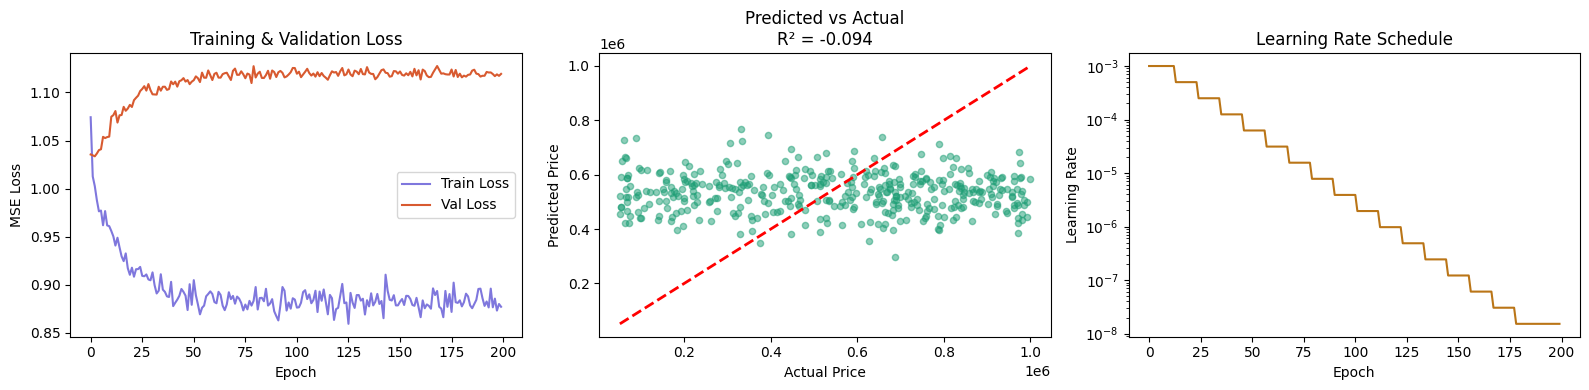

In [6]:
# Load best model
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    y_pred_sc = model(X_test_t).cpu().numpy()

# Inverse transform — back to original price scale
y_pred = scaler_y.inverse_transform(y_pred_sc)
y_true = scaler_y.inverse_transform(y_test_sc)

r2   = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"\nNeural Network Results:")
print(f"  R²:   {r2:.3f}")
print(f"  RMSE: ${rmse:,.0f}")

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='#7F77DD')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#D85A30')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Predicted vs Actual
axes[1].scatter(y_true, y_pred, alpha=0.5, color='#1D9E75', s=20)
axes[1].plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[1].set_title(f'Predicted vs Actual\nR² = {r2:.3f}')
axes[1].set_xlabel('Actual Price'); axes[1].set_ylabel('Predicted Price')

# Learning rate schedule
axes[2].plot(history['lr'], color='#BA7517')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')

plt.tight_layout(); plt.show()